# Variational quantum classifier

- Trains a `VQCClassifier` on a synthetic dataset, on the `torch` backend.
- Then composes two models into a `QuantumPipeline`.

### 1. Data

- `make_classification`, 200 samples, 4 features, 2 classes.
- `normalize="minmax"` is fit on the train split only.
- `AngleEmbedding` prescaling maps it to [0, pi] during `setup()`.

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

In [2]:
from pyqit import DataModule, set_backend

set_backend("torch")

dm = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

### 2. Model and training

- 4 qubits, 3 layers, `SELAnsatz`, `AngleEmbedding`.
- 15 epochs at lr 0.05.
- `fit` returns a `TrainingHistory`.

In [3]:
from pyqit import Trainer
from pyqit.ansatzes import SELAnsatz
from pyqit.core import AngleEmbedding
from pyqit.models import VQCClassifier

# Initialize the VQC
model = VQCClassifier(
    n_qubits=4,
    n_layers=3,
    n_classes=2,
    ansatz=SELAnsatz,
    encoder=AngleEmbedding,
)

# Set up the Trainer
trainer = Trainer(max_epochs=15, learning_rate=0.05)

history = trainer.fit(model, datamodule=dm)

 Parameter             Value          
 Model Name            VQCClassifier  
 Backend               Torch          
 Qubits                4              
 Ansatz                SELAnsatz      
 Encoder               AngleEmbedding 
 Trainable Params      36             
 Optimizer             ADAM           
 Learning Rate         0.05           
 Train / Val Samples   140 / 30       

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..


Output()

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

/home/aryan/PyQit/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: 
The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=15` reached.


[Trainer] Training complete.

### 3. Loss curve

- `history.as_dict()` returns the per-epoch metrics.

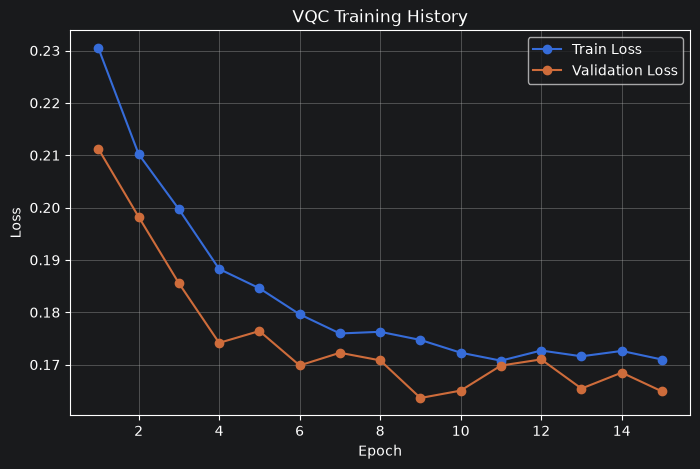

In [4]:
import matplotlib.pyplot as plt

# Extract metrics from the history
train_loss = history.as_dict()["train_loss"]
val_loss = history.as_dict()["val_loss"]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, val_loss, label="Validation Loss", marker="o")
plt.title("VQC Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4. Evaluation

- `predict` runs on the test split.
- `return_format="numpy"` forces numpy output on the torch backend.

Standalone VQC Test Accuracy: 83.33%


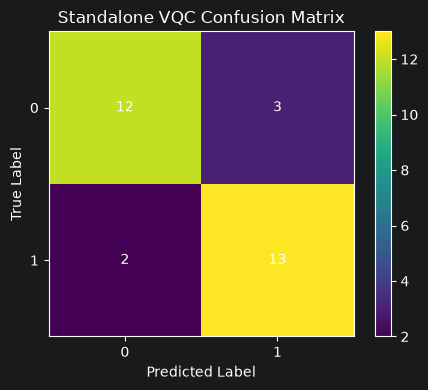

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict
predictions = trainer.predict(model, datamodule=dm, return_format="numpy")
actuals = dm.y_test.astype(int)

# Calculate Accuracy
acc = accuracy_score(actuals, predictions)
print(f"Standalone VQC Test Accuracy: {acc * 100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Standalone VQC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xticks(np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()

# Using `QuantumPipeline`

- Stage 1: 4-class backbone, frozen with `trainable=False`.
- Stage 2: trainable 2-class head.
- `mode="sequential"` feeds each stage's output to the next.
- `fit_mode="frozen_backbone"` on the pipeline trains only the head.
- Backend is switched back to `pennylane` first; the same `Trainer` then fits and predicts the pipeline exactly as it did the single model.

In [6]:
from pyqit import DataModule, set_backend

set_backend("pennylane")
dm_new = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

In [7]:
from pyqit.core import PipelineStage, QuantumPipeline

# Stage 1: The "Pre-trained" Backbone (Frozen)
backbone = VQCClassifier(n_qubits=4, n_layers=4, n_classes=4)
stage_1 = PipelineStage(backbone, name="feature_extractor", trainable=False)

# Stage 2: The Trainable Head
head = VQCClassifier(n_qubits=4, n_layers=1)
stage_2 = PipelineStage(head, name="classifier", trainable=True)

# Combine them into a Pipeline
pipeline = QuantumPipeline(
    [stage_1, stage_2], mode="sequential", fit_mode="frozen_backbone"
)
trainer_new = Trainer(max_epochs=40, learning_rate=0.2)

print("\nTraining Quantum Pipeline...")
history_new = trainer_new.fit(pipeline, datamodule=dm_new)


Training Quantum Pipeline...


[Pipeline] QuantumPipeline | mode=sequential | stages=2 | fit_mode=frozen_backbone

 #  Stage              Model          Qubits  Params  Status    
 1  feature_extractor  VQCClassifier  4       48      frozen    
 2  classifier         VQCClassifier  4       12      trainable

[2/2] Fitting stage 'classifier'

Output()

[Trainer] Training complete.

Pipeline Test Accuracy: 60.00%


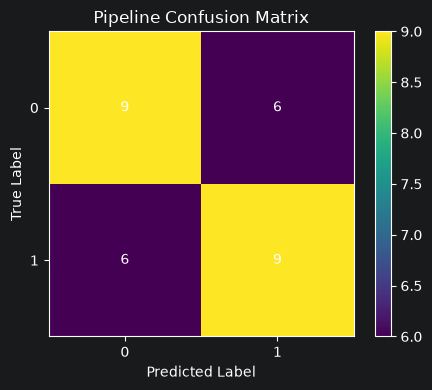

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

pipeline_preds = trainer_new.predict(pipeline, datamodule=dm_new, return_format="numpy")
actuals = dm_new.y_test

pipe_acc = accuracy_score(actuals, pipeline_preds)
print(f"Pipeline Test Accuracy: {pipe_acc * 100:.2f}%")

pipe_cm = confusion_matrix(actuals, pipeline_preds)

plt.figure(figsize=(5, 4))
plt.imshow(pipe_cm)
plt.title("Pipeline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(pipe_cm.shape[0]):
    for j in range(pipe_cm.shape[1]):
        plt.text(j, i, pipe_cm[i, j], ha="center", va="center")

plt.xticks(np.arange(pipe_cm.shape[1]))
plt.yticks(np.arange(pipe_cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()